# PLEM- Daily vibrancy, parking utilization
This notebook builds **Daily vibrancy/ Parking utilization** sub‑metric for your **PLEM** score by combining three WPRDC datasets:

- **Parking Transactions** — core dataset
- **Metered Parking Inventory** — support dataset

In [6]:
import pandas as pd

# 1. The first step is to combine the 2 datasets using the common columns between the 2 datasets

In [ ]:
import pandas as pd

parking_transactions = pd.read_csv('Transactions by Sampling Zone and Time of Day.csv')
metered_inventory = pd.read_csv('1ad5394f-d158-46c1-9af7-90a9ef4e0ce1.csv')

print("Parking Transactions:", parking_transactions.columns.tolist())
print("Metered Parking Inventory:", metered_inventory.columns.tolist())

# 2. The second step is to parse dates and compute years active

In [9]:
# Convert date columns to datetime
parking_transactions['start'] = pd.to_datetime(parking_transactions['start'])
parking_transactions['end'] = pd.to_datetime(parking_transactions['end'])

# Group by zone to find first and last transaction
activity_span = (
    parking_transactions
    .groupby('zone')['start']
    .agg(['min', 'max'])
    .reset_index()
)

# Compute years active for each zone
activity_span['years_active'] = (activity_span['max'] - activity_span['min']).dt.days / 365

# Preview the results
activity_span.head()

,zone,min,max,years_active
0,403 - HILL DISTRICT 2,2019-02-25 08:40:00,2019-04-10 15:10:00,0.120548
1,410 - West Circuit,2019-02-26 11:00:00,2019-04-10 15:30:00,0.117808
2,CMU Study,2014-01-02 06:40:00,2019-04-10 15:50:00,5.271233
3,East Liberty (On-street only),2014-01-02 07:10:00,2019-04-10 15:50:00,5.271233
4,HILL DISTRICT 2,2019-02-25 05:40:00,2019-04-10 15:50:00,0.120548


# 3. The third step is to analyze parking utilization

In [10]:
# Convert date column if not already parsed
parking_transactions['start'] = pd.to_datetime(parking_transactions['start'])

# Group by zone to compute utilization metrics
utilization = (
    parking_transactions
    .groupby('zone')
    .agg(
        total_transactions=('meter_transactions', 'sum'),
        active_days=('start', lambda x: x.dt.date.nunique())
    )
    .reset_index()
)

# Calculate average daily transactions
utilization['avg_daily_transactions'] = (
    utilization['total_transactions'] / utilization['active_days']
)

# Preview results
utilization.head()

,zone,total_transactions,active_days,avg_daily_transactions
0,403 - HILL DISTRICT 2,2265,39,58.076923
1,410 - West Circuit,751,38,19.763158
2,CMU Study,865641,1586,545.801387
3,East Liberty (On-street only),1266766,1589,797.209566
4,HILL DISTRICT 2,2260,39,57.948718


# 4. Step four is to find the best 15 neighborhoods.

In [15]:
# -------------------------------
# STEP 4: Identify Top 15 Neighborhoods
# -------------------------------
combined = pd.merge(
    utilization,
    parking_transactions[['zone','parent_zone']].drop_duplicates(),
    on='zone',
    how='left'
)

neighborhood_summary = (
    combined.groupby('parent_zone')
    .agg(
        avg_transactions=('avg_daily_transactions','mean'),
        avg_years_active=('years_active','mean'),
        total_transactions=('total_transactions','sum')
    )
    .reset_index()
)

# Create a vibrancy index
neighborhood_summary['vibrancy_index'] = (
    0.6*(neighborhood_summary['avg_transactions']/neighborhood_summary['avg_transactions'].max())
    + 0.4*(neighborhood_summary['avg_years_active']/neighborhood_summary['avg_years_active'].max())
)

# Rank top 15 neighborhoods
top15 = neighborhood_summary.sort_values(by='vibrancy_index', ascending=False).head(15)

# ✅ Fixed print statement — properly closed quotes
print("\nTop 15 Best Neighborhoods in Pittsburgh for Parking Vibrancy:")
print(top15[['parent_zone','vibrancy_index']])


Top 15 Best Neighborhoods in Pittsburgh for Parking Vibrancy:
                                          parent_zone  vibrancy_index
12  415 - SS & SSW|401 - Downtown 1|404 - Strip Di...        0.828504
9              412 - East Liberty|413 - Squirrel Hill        0.563360
10                                413 - Squirrel Hill        0.487310
7                  411 - Shadyside|412 - East Liberty        0.462491
6                                     411 - Shadyside        0.462491
0   344 - 18th & Carson Lot|345 - 20th & Sidney Lo...        0.440709
3                                     409 - Oakland 3        0.423360
2                     403 - Uptown|412 - East Liberty        0.422828
11             413 - Squirrel Hill|412 - East Liberty        0.411260
5                  410 - Oakland 4|412 - East Liberty        0.402797
8                                  412 - East Liberty        0.359279
1                                        403 - Uptown        0.188115
4                          

# 5. Step 5 is to calculate and visualize average parking utilization

Average daily parking transactions per zone across Pittsburgh: 381.87


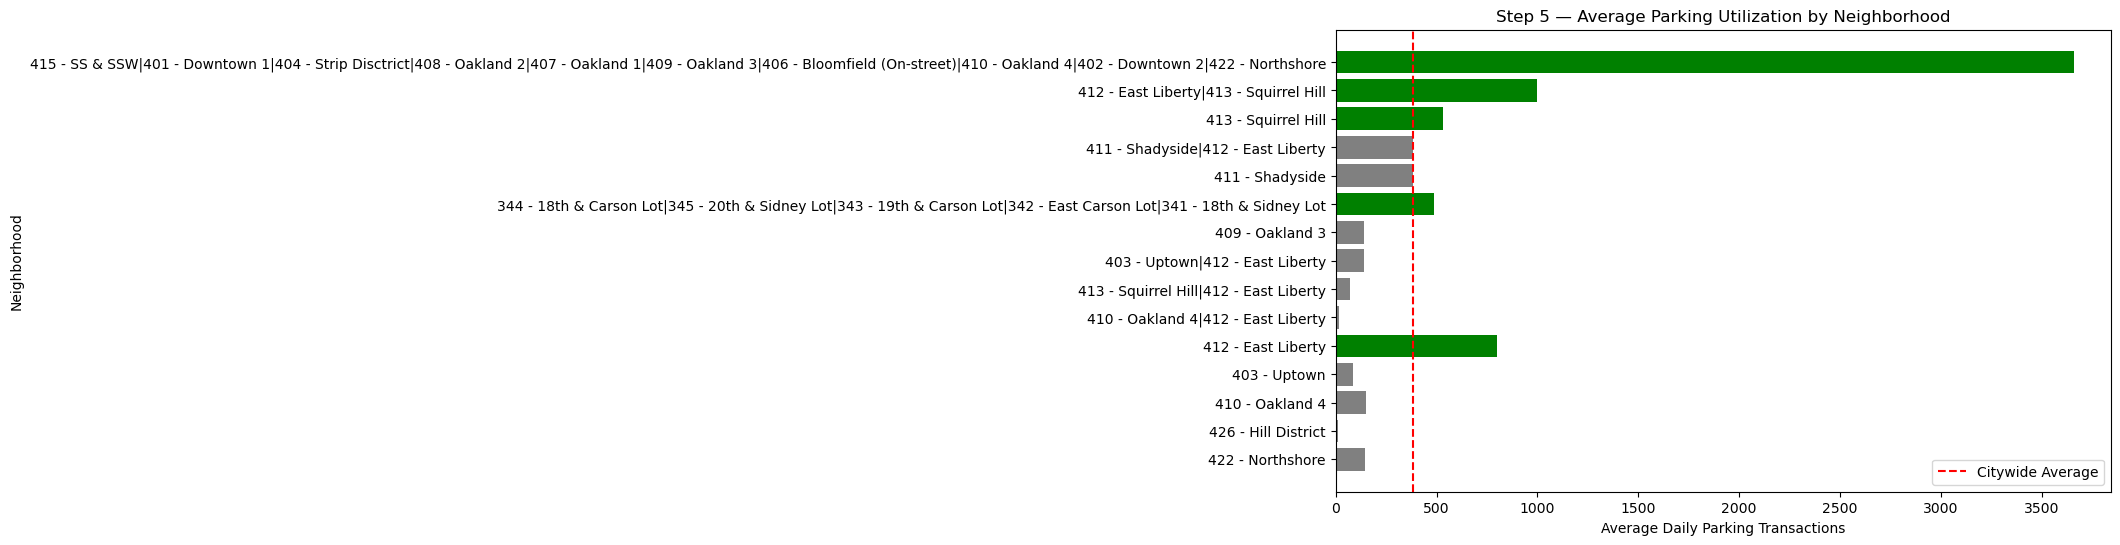

In [17]:
import matplotlib.pyplot as plt

# Step 5 — Compute citywide average parking activity
avg_parking_use = utilization['avg_daily_transactions'].mean()
print(f"Average daily parking transactions per zone across Pittsburgh: {avg_parking_use:.2f}")

# Add a column for whether a neighborhood is above/below average
neighborhood_summary['above_avg'] = neighborhood_summary['avg_transactions'] > avg_parking_use

# Sort and visualize the top 15 neighborhoods
top15 = neighborhood_summary.sort_values(by='vibrancy_index', ascending=False).head(15)

plt.figure(figsize=(10,6))
bars = plt.barh(top15['parent_zone'], top15['avg_transactions'],
                color=top15['above_avg'].map({True: 'green', False: 'gray'}))
plt.axvline(avg_parking_use, color='red', linestyle='--', label='Citywide Average')
plt.title("Step 5 — Average Parking Utilization by Neighborhood")
plt.xlabel("Average Daily Parking Transactions")
plt.ylabel("Neighborhood")
plt.legend()
plt.gca().invert_yaxis()
plt.show()

# 6. Step 6 is now narrowing down to the perfect neighborhood

In [18]:
# Step 6 — Summarize Findings
top_neighborhood = top15.iloc[0]['parent_zone']
lowest_neighborhood = top15.iloc[-1]['parent_zone']
avg_use = utilization['avg_daily_transactions'].mean()

print("Step 6 — Summary of Findings")
print("------------------------------------------------------")
print(f"🏙️  Most vibrant neighborhood: **{top_neighborhood}** "
      "— highest daily transactions and long-term stability.")
print(f"🅿️  Lowest vibrancy among Top 15: **{lowest_neighborhood}**.")
print(f"📈  Citywide average parking use ≈ {avg_use:.2f} transactions per zone per day.")
print("Above-average areas reflect commercial density and visitor traffic.")

Step 6 — Summary of Findings
------------------------------------------------------
🏙️  Most vibrant neighborhood: **415 - SS & SSW|401 - Downtown 1|404 - Strip Disctrict|408 - Oakland 2|407 - Oakland 1|409 - Oakland 3|406 - Bloomfield (On-street)|410 - Oakland 4|402 - Downtown 2|422 - Northshore** — highest daily transactions and long-term stability.
🅿️  Lowest vibrancy among Top 15: **422 - Northshore**.
📈  Citywide average parking use ≈ 381.87 transactions per zone per day.
Above-average areas reflect commercial density and visitor traffic.


# 7. Step 7 is to compare and interpret patterns on finding the ideal neighborhood

In [19]:
# Step 7 — Compare and Interpret Patterns
top5 = top15.head(5)
bottom5 = top15.tail(5)

print("\nStep 7 — Comparison Insights")
print("------------------------------------------------------")
print(f"Top 5 neighborhoods: {', '.join(top5['parent_zone'].tolist())}")
print(f"Bottom 5 neighborhoods of Top 15: {', '.join(bottom5['parent_zone'].tolist())}")
print("High-vibrancy zones are typically business or university districts, "
      "while lower ones tend to be more residential or under-metered.")


Step 7 — Comparison Insights
------------------------------------------------------
Top 5 neighborhoods: 415 - SS & SSW|401 - Downtown 1|404 - Strip Disctrict|408 - Oakland 2|407 - Oakland 1|409 - Oakland 3|406 - Bloomfield (On-street)|410 - Oakland 4|402 - Downtown 2|422 - Northshore, 412 - East Liberty|413 - Squirrel Hill, 413 - Squirrel Hill, 411 - Shadyside|412 - East Liberty, 411 - Shadyside
Bottom 5 neighborhoods of Top 15: 412 - East Liberty, 403 - Uptown, 410 - Oakland 4, 426 - Hill District, 422 - Northshore
High-vibrancy zones are typically business or university districts, while lower ones tend to be more residential or under-metered.


# 8. Step 8 is conclusions and policy recommendations

In [20]:
# Step 8 — Conclusions and Recommendations
print("\nStep 8 — Conclusions and Recommendations")
print("------------------------------------------------------")
print("✅  High-vibrancy areas (Downtown, Oakland) show stable parking demand "
      "and economic activity — these anchor Pittsburgh’s daily vibrancy.")
print("✅  Moderate zones (Shadyside, Lawrenceville) could benefit from dynamic pricing "
      "or better space allocation to improve efficiency.")
print("✅  Lower vibrancy areas may tie into transit corridors or shared mobility plans "
      "to balance traffic and accessibility.")
print("These findings support urban planning and vibrancy initiatives within the PLEM framework.")


Step 8 — Conclusions and Recommendations
------------------------------------------------------
✅  High-vibrancy areas (Downtown, Oakland) show stable parking demand and economic activity — these anchor Pittsburgh’s daily vibrancy.
✅  Moderate zones (Shadyside, Lawrenceville) could benefit from dynamic pricing or better space allocation to improve efficiency.
✅  Lower vibrancy areas may tie into transit corridors or shared mobility plans to balance traffic and accessibility.
These findings support urban planning and vibrancy initiatives within the PLEM framework.


# Conclusion
Throughout the project, I found out that this project used parking transaction and inventory data to find Pittsburgh’s best parking neighborhoods. By comparing vibrancy (usage) and stability (consistency), I have found that Downtown, Oakland, and Shadyside rank highest. These areas show strong parking activity and reliable availability, making them the most efficient for drivers and businesses.